# Begin

In [121]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import queue
import glob

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Categorical
from torch.nn.attention import SDPBackend, sdpa_kernel

import gymnasium as gym
import ale_py
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import av

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement

# Init

In [2]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [3]:
# @launchit.collect_temp_config
# @launchit.disable

# Construct temporary CONFIG object for build and bootstrap purposes
if '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    
    if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
        # This (bootstrap) config is for the very initial phase of docker launch when one needs to load hyperparameters.
        # This config will be recreated soon to full-fledged Config
        CONFIG = namedtuple('BootstrapConfig', 'initrd_path, exec_mode')(
            initrd_path=os.path.join(project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK,
        )
        assert Logging._instance is None, 'Must create Logging instance with use_raw_stdout=True, but Logging instance is already created'
        # use_raw_stdout is necessary because sys.stdout is hijacked by papermill and this will lead to problems
        # with string duplications written to stdout by child process (worker)
        # see https://share.google/aimode/ffIcoqyaJdgMsEcoW
        Logging.get(use_raw_stdout=True)    
    else:
        # Config to build docker launch
        CONFIG = namedtuple('BuildConfig', 
                            'initrd_path, relative_initrd_path, relative_run_path, relative_metrics_suite_fname, ' + 
                            'model_group_uri, self_fname, relative_self_fname, self_name, subproject_name, ' + 
                            'docker_registry, exec_mode, ' +
                            'artifact_registry_cache, artifact_registry')(
            initrd_path=os.path.join(build_project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            relative_initrd_path=os.path.join('run', subproject_name, 'initrd-' + notebook_name), # relative to build project root
            relative_run_path=os.path.join('run', subproject_name),
            relative_metrics_suite_fname=os.path.join('run', subproject_name, notebook_name + '.metrics_suite.json'),
            model_group_uri='${MODEL_GROUP_URI}',
            self_fname=notebook_fname,
            relative_self_fname=lu.when('/run/' in notebook_fname, 'run/', '') + os.path.join(subproject_name, notebook_basename),  # relative to build project root
            self_name=notebook_name,
            subproject_name=subproject_name,
            docker_registry='cr.selcloud.ru/neurolab',
            exec_mode=ExecMode.LAUNCH_NOTEBOOK,
            artifact_registry_cache={}, 
            artifact_registry=None,
        )
        CONFIG = CONFIG._replace(artifact_registry=ArtifactRegistry(CONFIG.model_group_uri, cache=CONFIG.artifact_registry_cache))
        os.makedirs(CONFIG.initrd_path, exist_ok=True)

    Logging.get()(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n')
# @launchit.stop

In [4]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )

    env_cuda_device = os.environ.get('CUDA_DEVICE')
    
    if torch.cuda.is_available():
        default_cuda_device = 'cuda'
        config = config._replace(cuda_device=lu.coalesce(env_cuda_device, default_cuda_device))
    else:
        assert env_cuda_device is None, f'CUDA device "{env_cuda_device}" is requested but CUDA is NOT available!'
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [5]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
LOG(f'{os.environ=}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'thinkbook',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.18_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/18_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/18_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/18_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/18_rl/initrd-18a_test_pack_01',
 'self_fname': '/home/misha/dev/mine/neurolab/18_rl/18a_test_pack_01.ipynb',
 'self_name': '18a_test_pack_01',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/18_rl/18a_test_pack_01.metrics_suite.json',
 'subproject_name': '18_rl',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [22]:
ARTIFACT_REGISTRY = ArtifactRegistry(CONFIG.model_group_uri)

# Step 1: configure

In [123]:
TEST_PACK_NAME = 'test_pack'
SPOOL_DIR_NAME = os.path.join(CONFIG.run_path, TEST_PACK_NAME)
os.makedirs(SPOOL_DIR_NAME, exist_ok=True)
pack_items = glob.glob(os.path.join(SPOOL_DIR_NAME, '*.pkl'))
print(pack_items)
print(f'{len(pack_items)} pack items found')

['/home/misha/dev/mine/neurolab/run/18_rl/test_pack/item-331-7.pkl']
1 pack items found


In [49]:
AGENT_ID = 'com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162'
AGENT, AGENT_HP = NOTEBOOK_MODULE.load_agent(AGENT_ID, ARTIFACT_REGISTRY, create_instance=True)

In [58]:
TARGET_NOTEBOOK_FNAME = '18a_world_model_01.ipynb'
source_code = launchit.extract_source_code(TARGET_NOTEBOOK_FNAME, collect_inds=[None, 'explore'])
NOTEBOOK_MODULE = lu.make_module('target_notebook', source_code)
NOTEBOOK_MODULE.CONFIG = CONFIG
NOTEBOOK_MODULE.RNG = RNG
NOTEBOOK_MODULE.LOG = LOG

In [59]:
# WorldModel is req-d here only for preprocess purposeses, so the only important param is ob_shape
wmp = NOTEBOOK_MODULE.WorldModel.Params(
    d_model=256,
    layers_count=3,
    heads_count=4,
    actions_count=AGENT.params.actions_count,
    ob_shape=(1, 178, 152),
    ob_grid_shape=(16, 16),
    sequence_length=4,
    attention_backend='FLASH_ATTENTION',
)
WORLD_MODEL = NOTEBOOK_MODULE.WorldModel(wmp)

# Step 2: generate

In [60]:
envs_count = 1
sequence_length = WORLD_MODEL.params.sequence_length + 1
rollout_steps_count = 512
DATASET = NOTEBOOK_MODULE.Dataset(
    envs_count=envs_count,
    ob_shape=WORLD_MODEL.params.ob_shape, 
    rollout_steps_count=rollout_steps_count, 
    sequence_length=sequence_length, 
    actions_count=AGENT.params.actions_count,
    batches_count=1,
    is_shuffled=False,
)
ROLLOUT_MANAGER = NOTEBOOK_MODULE.RolloutManager(
    agent_sequence_length=AGENT.params.obs_sequence_length, 
    agent_ob_shape=AGENT.params.observation_space_shape,
    sequence_length=sequence_length,
    ob_shape=WORLD_MODEL.params.ob_shape,
    env_id=AGENT_HP['env']['ident'],
    envs_count=envs_count, 
)
ROLLOUT_MANAGER.reset(
    agent=AGENT, 
    world_model=WORLD_MODEL,
    random_seed=42,
)
ROLLOUT_MANAGER.rollout(AGENT, WORLD_MODEL, DATASET, steps_count=rollout_steps_count)
BATCH = next(iter(DATASET))

Envs created: 1 envs, thread_pool_size=None, thread_affinity_offset=None
Envs reset


# Step 3: select

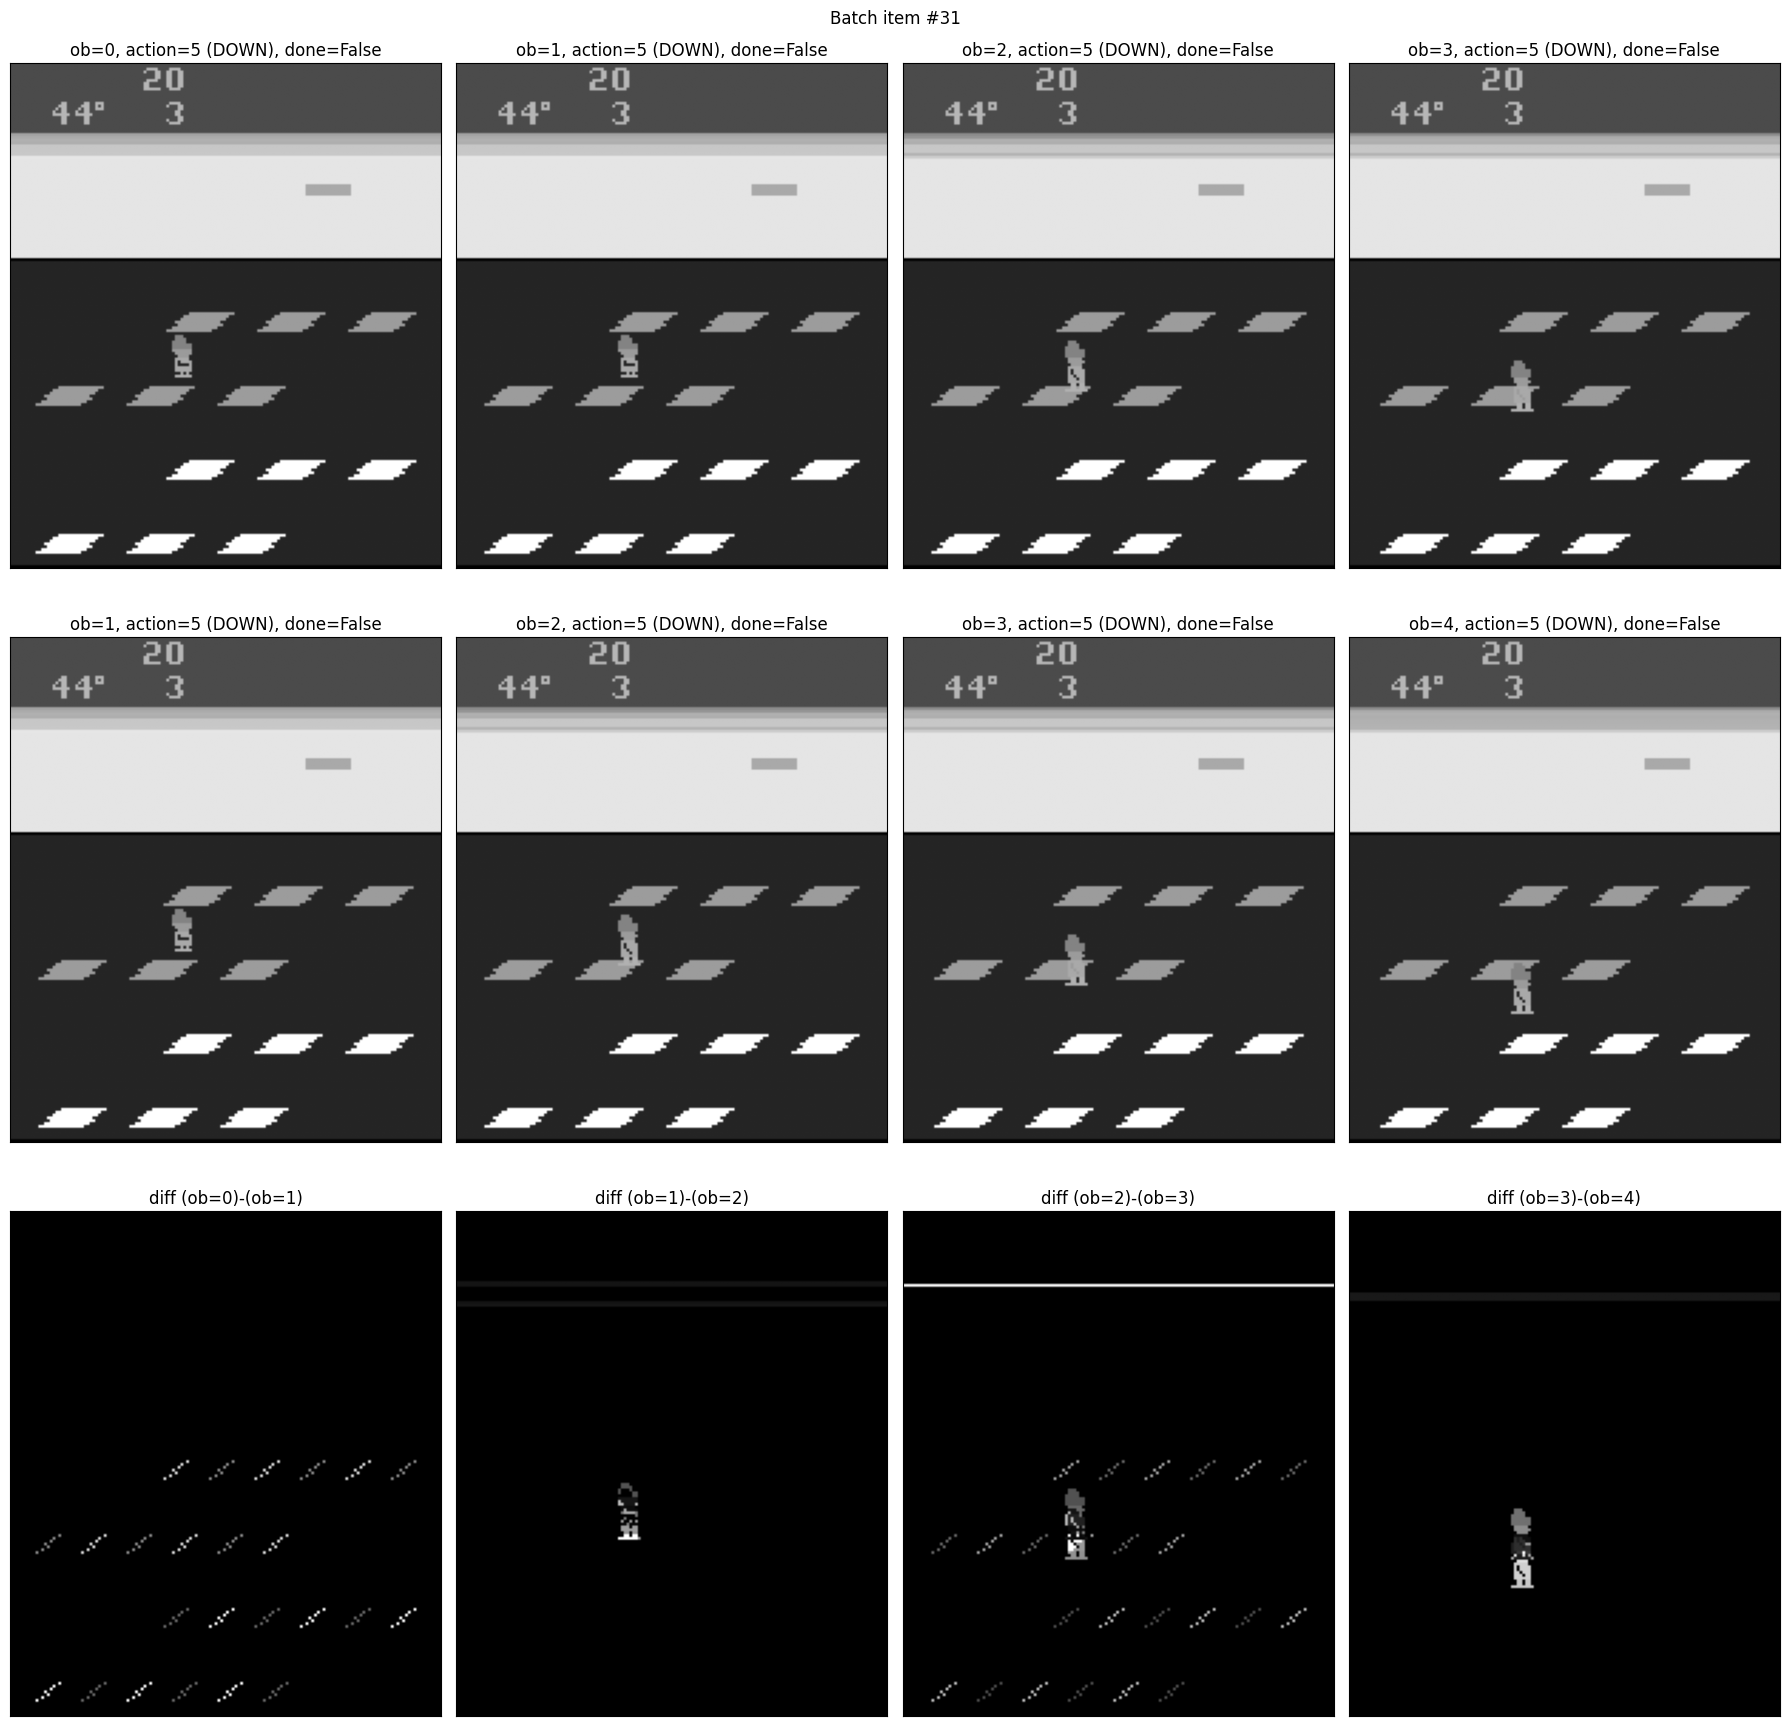

In [167]:
fig, axes = plt.subplots(3, WORLD_MODEL.params.sequence_length)
fig.set_figwidth(18)
fig.set_figheight(6 * len(axes))

batch_mask = BATCH.pmasks.sum(axis=1) == 0
BATCH = BATCH._replace(
    obs=BATCH.obs[batch_mask],
    actions=BATCH.actions[batch_mask],
    pmasks=BATCH.pmasks[batch_mask],
    dones=BATCH.dones[batch_mask],
)

b_ind = RNG.choice(len(BATCH.obs))
actions = BATCH.actions[b_ind,:-1]
obs = BATCH.obs[b_ind,:-1]
next_obs = BATCH.obs[b_ind,1:]
dones = BATCH.dones[b_ind]

fig.suptitle(f'Batch item #{b_ind}')

for i, (action, ob, next_ob, done) in enumerate(zip(actions, obs, next_obs, dones)):
    kwargs = dict(cmap='gray')
    # kwargs = dict()
    action_name = ale_py.Action(action.item()).name
    axes[0,i].set_title(f'ob={i}, action={action} ({action_name}), done={dones[i].bool()}')
    axes[0,i].imshow(ob.squeeze(0), **kwargs)
    axes[1,i].set_title(f'ob={i+1}, action={action} ({action_name}), done={dones[i+1].bool()}')
    axes[1,i].imshow(next_ob.squeeze(0), **kwargs)
    axes[2,i].set_title(f'diff (ob={i})-(ob={i+1})')
    axes[2,i].imshow((ob - next_ob).squeeze(0), **kwargs)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()

In [168]:
pack_item = dict(
    pmasks=BATCH.pmasks[b_ind].cpu(),
    obs=BATCH.obs[b_ind].cpu(),
    actions=BATCH.actions[b_ind].cpu(),
    dones=BATCH.dones[b_ind].cpu(),
)
pack_item_serial = Autoincrement.get(CONFIG.model_group_uri + '.test_packs')
pack_item_name = f'item-{b_ind}-{pack_item_serial}.pkl'
pack_item_fname = os.path.join(SPOOL_DIR_NAME, pack_item_name)

with open(pack_item_fname, 'wb') as f:
    pickle.dump(pack_item, f)

print(f'Pack item saved to "{pack_item_fname}"')

Pack item saved to "/home/misha/dev/mine/neurolab/run/18_rl/test_pack/item-31-17.pkl"


# Step 4: pack

In [169]:
test_pack = dict(
    pmasks=[],
    obs=[],
    actions=[],
    dones=[],
)

for pack_item_fname in glob.glob(os.path.join(SPOOL_DIR_NAME, '*.pkl')):
    with open(pack_item_fname, 'rb') as f:
        pack_item = pickle.load(f)

    for key in pack:
        test_pack[key].append(pack_item[key].unsqueeze(0))

for key in test_pack:
    test_pack[key] = torch.cat(test_pack[key], axis=0)
    print(f'{key}.shape={test_pack[key].shape}')

test_pack_version = Autoincrement.get(CONFIG.model_group_uri + '.' + TEST_PACK_NAME)
ARTIFACT_REGISTRY.register_component(TEST_PACK_NAME, test_pack_version)
print(f'{test_pack_version=}')

with io.BytesIO() as b:
    pickle.dump(test_pack, b)
    ARTIFACT_REGISTRY.attach_asset(TEST_PACK_NAME, test_pack_version, b, asset_ext='pkl');

pmasks.shape=torch.Size([5, 5])
obs.shape=torch.Size([5, 5, 1, 178, 152])
actions.shape=torch.Size([5, 5])
dones.shape=torch.Size([5, 5])
test_pack_version='9'
.pkl asset attached to com.develorium.neurolab.18_rl.test_pack:9


# Step 5: verify

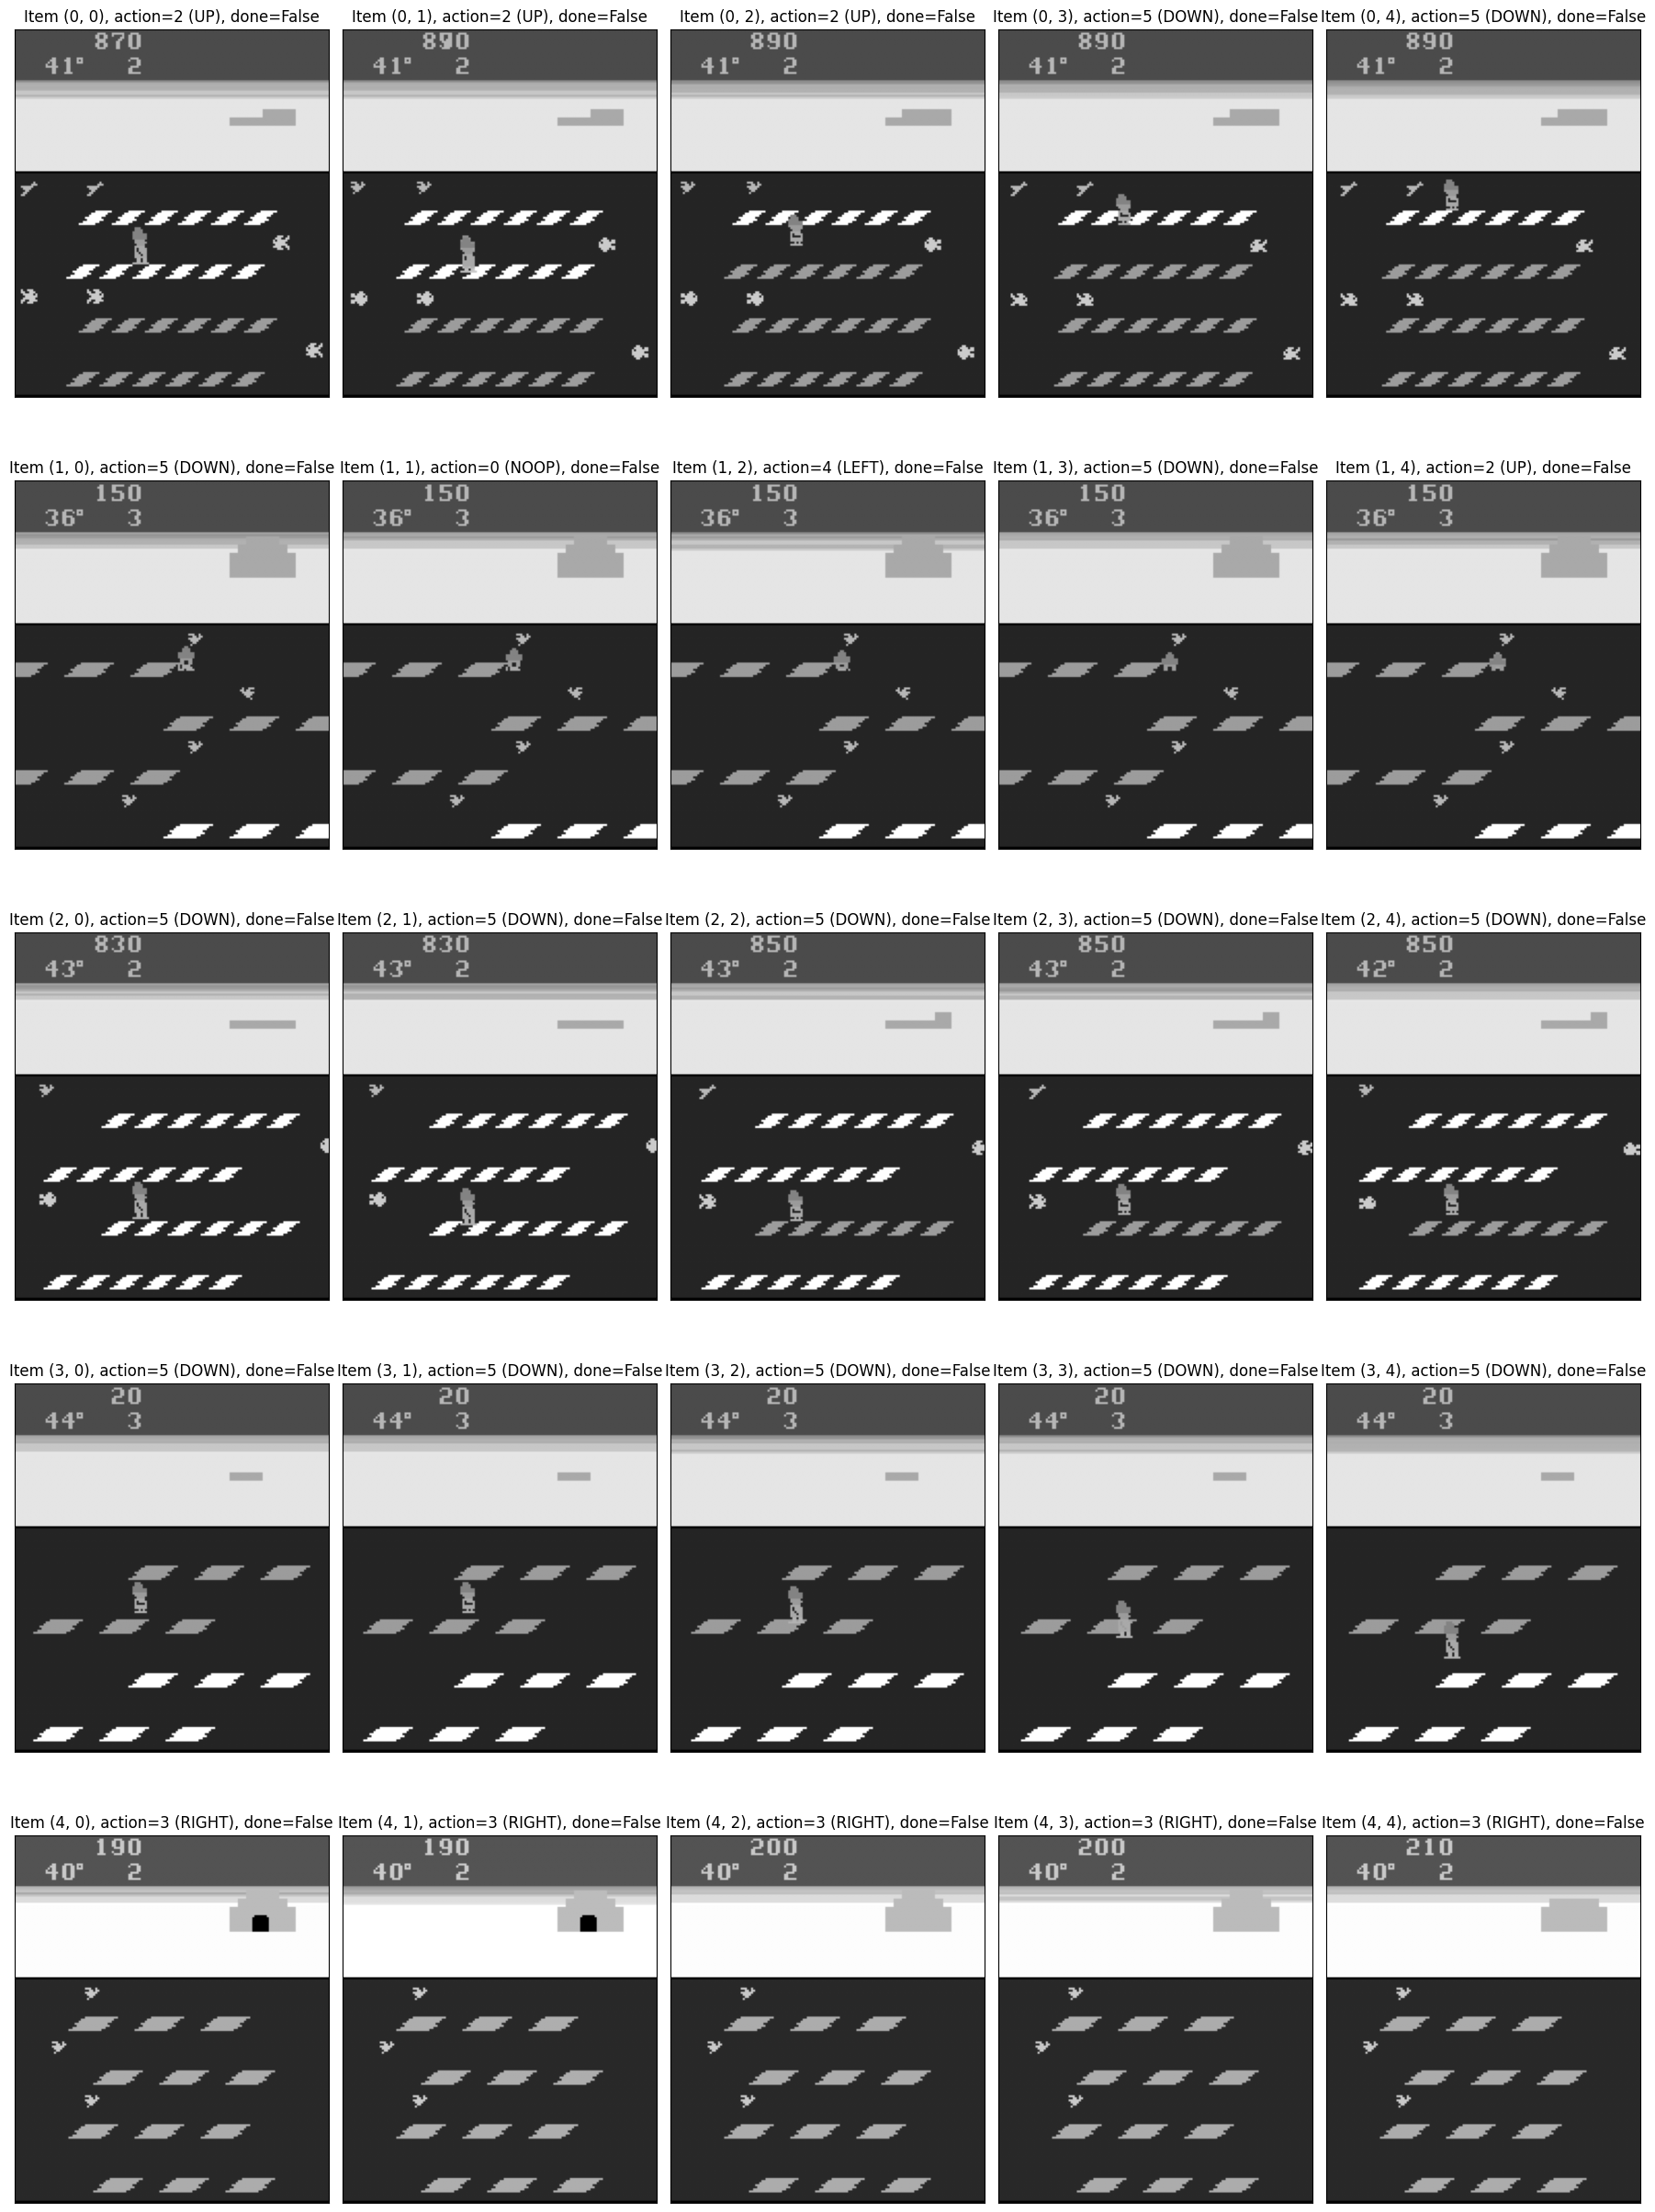

In [190]:
TEST_PACK_ID = 'com.develorium.neurolab.18_rl:test_pack:9'
coords = hp_parse_artifact_source(TEST_PACK_ID)
test_pack_pkl = ARTIFACT_REGISTRY.get_asset_content(coords.model_name, coords.model_version, asset_ext='pkl')

with io.BytesIO(test_pack_pkl) as b:
    test_pack = pickle.load(b)

l = len(test_pack['obs'])
s = test_pack['obs'].shape[1]
fig, axes = plt.subplots(l, s)
fig.set_figwidth(18)
fig.set_figheight(5 * len(axes))

for i, (pmasks, obs, actions, dones) in enumerate(zip(test_pack['pmasks'], test_pack['obs'], test_pack['actions'], test_pack['dones'])):
    for j, ax in enumerate(axes[i]):
        kwargs = dict(cmap='gray')
        action_name = ale_py.Action(actions[j].item()).name
        ax.set_title(f'Item {i,j}, action={actions[j]} ({action_name}), done={dones[j].bool()}')
        ax.imshow(obs[j].squeeze(0), **kwargs)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()